In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('Indian_Names.txt', 'r').read().lower().splitlines()
words[:9]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh']

In [3]:
len(words)

53982

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context lenght : how many characters do we take to predict the next move
X,Y = [],[] # X : input to neural net  
            # Y : is label of input inside the X

for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([488074, 3]), torch.int64, torch.Size([488074]), torch.int64)

In [41]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([390591, 3]) torch.Size([390591])
torch.Size([48694, 3]) torch.Size([48694])
torch.Size([48789, 3]) torch.Size([48789])


In [42]:
len(words)

53982

In [44]:
n1

43185

In [45]:
n2

48583

In [46]:
n2-n1

5398

In [47]:
len(words) - n2

5399

In [7]:
c = torch.randn((27,2))

In [8]:
c[5]

tensor([ 2.0445, -1.6065])

In [9]:
c[torch.tensor([5,6,7])]

tensor([[ 2.0445, -1.6065],
        [-0.1837,  0.2004],
        [ 0.2176, -0.1123]])

In [32]:
c[X].shape

torch.Size([37, 3, 2])

In [33]:
X[13,2]

tensor(1)

In [34]:
c[X][13,2]

tensor([0.4806, 0.1012])

In [ ]:
"""
    One-Hot Encoding Approach: You take an integer (e.g., 5), turn it into a vector of all zeros with a 1 at the 5th index,
    and multiply that vector by your embedding matrix C. Because of the properties of matrix multiplication, this 
    operation effectively "masks out" every row in C except for the one at index 5, returning that specific embedding vector.
     
    The Indexing Shortcut: C[x] does exactly the same thing but much more efficiently. It directly "plucks out" the row 
    at the given index without having to perform the redundant multiplication with thousands of zeros.
    
    Why it matters:
    Using C[x] is the standard way to implement embeddings in PyTorch because it is significantly faster and uses less 
    memory than constructing massive one-hot tensors. It essentially allows the first layer of the neural network to act
    as a learnable lookup table, where the "weights" of the layer are the embedding vectors themselves.
"""

In [62]:
emb = c[X]
emb.shape

torch.Size([37, 3, 2])

In [63]:
w1 = torch.randn([6,100])
b1 = torch.randn(100)

In [64]:
emb @ w1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (111x2 and 6x100)

In [65]:
#it didnt worked as emb is [37,3,2] and w1 is [6,100] and b1 is [100] so to actually multiply we need 
# to convert [37,3,2] in to [37,6]

In [66]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([37, 6])

In [67]:
torch.cat(torch.unbind(emb, 1),1).shape

torch.Size([37, 6])

In [73]:
emb.view(37,6).shape

torch.Size([37, 6])

In [78]:
# so we can either concatne it via torch.cat 
# or we can just use emb.view() and it just automatically change the shape of the matrix
# cat is much more inefficient that view 
# view is more efficient

In [81]:
# therefore
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
h

tensor([[-0.2679, -0.0411, -1.0000,  ..., -0.9812,  0.6763, -0.4913],
        [-0.3825, -0.4386, -0.9999,  ..., -0.9928,  0.4842, -0.8590],
        [-0.2590, -0.2977, -0.9987,  ..., -0.9976,  0.0980, -0.0418],
        ...,
        [-0.1818,  0.3029, -0.6479,  ..., -0.3033, -0.6134, -0.1728],
        [-0.6586,  0.9762,  0.4233,  ..., -0.6594,  0.3939, -0.8546],
        [-0.0122,  0.9789, -0.1417,  ..., -0.4170,  0.0373, -0.9662]])

In [82]:
h.shape

torch.Size([37, 100])

In [84]:
(emb.view(-1,6) @ w1).shape

torch.Size([37, 100])

In [85]:
b1.shape

torch.Size([100])

In [87]:
# 32, 100
#   , 100

# while broadcasting it will create a new dimension

# 32, 100
#  1, 100

# it will copy vertically for every one of this row of 32 and do a element wise addition
# why correction : because same bias vector will be added to the rows of this vector      emb.view(-1,6) @ w1

In [88]:
w2 = torch.randn([100,27])
b2 = torch.randn(27)

In [89]:
logits = h @ w2 + b2

In [90]:
logits.shape

torch.Size([37, 27])

In [91]:
counts = logits.exp()

In [101]:
prob = counts / counts.sum(1, keepdims = True)

In [102]:
print(probs.shape)
probs[0].sum()

torch.Size([37, 27])


tensor(1.)

In [105]:
torch.arange(37)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36])

In [106]:
Y

tensor([ 1,  1,  2,  1, 14,  0,  1,  1,  2,  8,  1, 18,  1, 14,  0,  1,  1,  2,
         8,  1, 19,  0,  1,  1,  2,  8,  1, 20,  0,  1,  1,  2,  8,  5,  5, 18,
         0])

In [109]:
loss = -prob[torch.arange(37), Y].log().mean()
loss

tensor(13.5967)

In [97]:
# ------------ losss ---------------

In [107]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([390591, 3]), torch.Size([390591]))

In [137]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [138]:
sum(p.nelement() for p in parameters) # number of parameters in total

17697

In [139]:
C[X].shape

torch.Size([488074, 3, 10])

In [142]:
emb = C[X] # (37,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(37), Y].log().mean()
loss = F.cross_entropy(logits, Y) # this works same as 
# this make forward and backward pass much more efficient things can be much more well bwhaved

loss

tensor(32.7928)

In [143]:
h.shape

torch.Size([488074, 300])

In [144]:
for p in parameters :
    p.requires_grad =  True

In [145]:
lre = torch.linspace(-3, 0, 30000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010,  ..., 0.9995, 0.9998, 1.0000])

In [147]:
lri = []
lossi = []
stepi = []

In [163]:

for i in range (50000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass 
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) 
    #print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    #lr = lrs[i]

    lr = 0.0001
    #lr = 0.001  #deduced via lres and lre via plot given below
    #lr = 0.01
    #lr = 0.1
    #lr = 0.5
    for p in parameters:
        p.data += -lr * p.grad

    # track state
    #lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)
loss.item()

1.4656100273132324

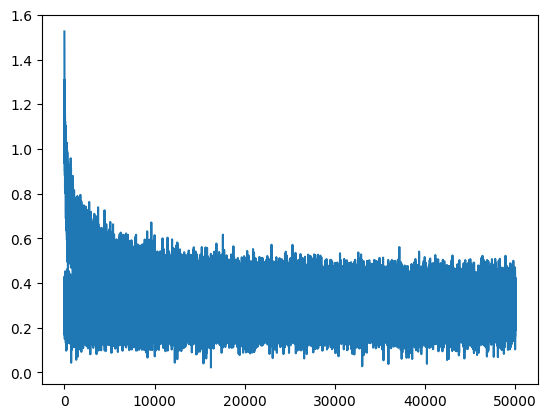

In [164]:
plt.plot(stepi, lossi)

In [165]:
# training loss 
emb = C[Xtr] 
h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) 
print(loss.item())

1.938196063041687


In [166]:
# dev loss
emb = C[Xdev] 
h = torch.tanh(emb.view(-1,30) @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) 
print(loss.item())

1.9546971321105957


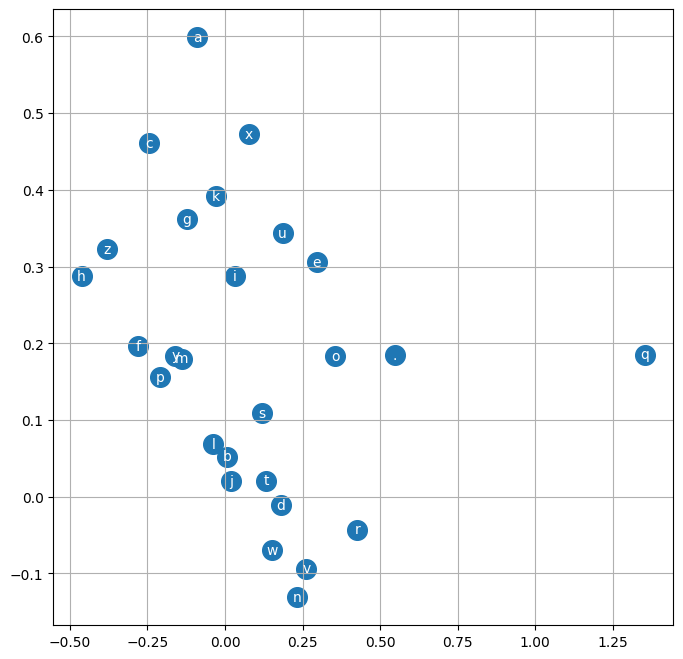

In [167]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [168]:
torch.randint(0, X.shape[0], (32,))

tensor([ 35652,  45828, 468282,  45804, 136366, 270595, 310280, 449742,  80228,
        318795, 301920,  43649, 100950, 265663, 311879, 281940, 177009, 384012,
        293492, 315635, 170804, 469239, 256012,  65796, 325689, 181686,  45409,
        187039, 147232, 247895, 239843, 234143])

In [169]:
# training split, val set, test set 
# 80 , 10 , 10

In [170]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [171]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

chamahesh.
jhavithimritheethankan.
saethahuthan.
virathigeet.
neethishanaiha.
kaleka.
dham.
poon.
eshan.
sulilaa.
vidhi.
rajeep.
devrisika.
jeevinu.
thes.
edi.
abetha.
hasri.
aarasmithanksya.
pumara.
